In [29]:
import pandas as pd
import pathlib

from datavis import visualize_atom_importance_from_mol
from mpnn import MoleculeFDetector
from xai_methods import IGAttributionMethod

In [76]:
artifacts_dirs_default_readout = [
    pathlib.Path("artifacts/explainability_method_tester/20260416_205939"),
    pathlib.Path("artifacts/explainability_method_tester/20260417_092239"),
    pathlib.Path("artifacts/explainability_method_tester/20260419_225058"),
    pathlib.Path("artifacts/explainability_method_tester/20260420_101509")
]

artifacts_dirs_max_readout = [
    pathlib.Path("artifacts/explainability_method_tester/20260420_215626")
]

whitebox_to_path = {}

for artifacts_dir in artifacts_dirs_default_readout:
    for entry in artifacts_dir.iterdir():
        if entry.is_dir():
            whitebox_to_path[entry.name] = entry

In [77]:
positive_dfs, negative_dfs = [], []

for whitebox, path in whitebox_to_path.items():
    positive_df = pd.read_csv(path / "positive_explainability_results.csv")
    negative_df = pd.read_csv(path / "negative_explainability_results.csv")

    positive_dfs.append((whitebox, positive_df))
    negative_dfs.append((whitebox, negative_df))



In [90]:
for whitebox, positive_df in positive_dfs:
    print(f"Whitebox: {whitebox}")
    df_numerical = positive_df.drop(columns="SMILES")

    for column in df_numerical[["GNN Explainer_auroc"]]:
        mean_value = df_numerical[column].mean()
        print(f"  {column}: {mean_value:.4f}")

    print("=" * 40)

Whitebox: MoleculeJDetector
  GNN Explainer_auroc: 0.5000
Whitebox: MoleculeGDetector
  GNN Explainer_auroc: 0.5000
Whitebox: MoleculeFDetector
  GNN Explainer_auroc: 0.5000
Whitebox: MoleculeIDetector
  GNN Explainer_auroc: 0.5000
Whitebox: MoleculeHDetector
  GNN Explainer_auroc: 0.5000
Whitebox: MoleculeCDetector
  GNN Explainer_auroc: 0.5000
Whitebox: MoleculeEDetector
  GNN Explainer_auroc: 0.5000
Whitebox: MoleculeKDetector
  GNN Explainer_auroc: 0.5000
Whitebox: MoleculeLDetector
  GNN Explainer_auroc: 0.5000
Whitebox: MoleculeMDetector
  GNN Explainer_auroc: 0.5000
Whitebox: MoleculeODetector
  GNN Explainer_auroc: 1.0000
Whitebox: MoleculeNDetector
  GNN Explainer_auroc: 0.5000
Whitebox: MoleculePDetector
  GNN Explainer_auroc: 0.5000
Whitebox: MoleculeQDetector
  GNN Explainer_auroc: 0.5000


In [79]:
for whitebox, negative_df in negative_dfs:
    print(f"Whitebox: {whitebox}")
    df_numerical = negative_df.drop(columns="SMILES")

    for column in df_numerical.columns:
        mean_value = df_numerical[column].mean()
        print(f"  {column}: {mean_value:.4f}")

    print("=" * 40)

Whitebox: MoleculeJDetector
  Integrated Gradients: 1.0000
  Saliency: 1.0000
  SHAP Sampling: 1.0000
  Input x Gradient: 1.0000
  GNN Explainer: 1.0000
  PG Explainer: 1.0000
Whitebox: MoleculeGDetector
  Integrated Gradients: 1.0000
  Saliency: 1.0000
  SHAP Sampling: 1.0000
  Input x Gradient: 1.0000
  GNN Explainer: 1.0000
  PG Explainer: 1.0000
Whitebox: MoleculeFDetector
  Integrated Gradients: 1.0000
  Saliency: 1.0000
  SHAP Sampling: 1.0000
  Input x Gradient: 1.0000
  GNN Explainer: 1.0000
  PG Explainer: 1.0000
Whitebox: MoleculeIDetector
  Integrated Gradients: 1.0000
  Saliency: 1.0000
  SHAP Sampling: 1.0000
  Input x Gradient: 1.0000
  GNN Explainer: 1.0000
  PG Explainer: 1.0000
Whitebox: MoleculeHDetector
  Integrated Gradients: 1.0000
  Saliency: 1.0000
  SHAP Sampling: 1.0000
  Input x Gradient: 1.0000
  GNN Explainer: 1.0000
  PG Explainer: 1.0000
Whitebox: MoleculeCDetector
  Integrated Gradients: 1.0000
  Saliency: 1.0000
  SHAP Sampling: 1.0000
  Input x Gradient

In [80]:
hard_samples = {}

for whitebox, positive_df in positive_dfs:
    gradient_hard = (positive_df["Input x Gradient_auroc"] < 1) & (positive_df["Integrated Gradients_auroc"] < 1) & \
                    (positive_df["Saliency_auroc"] < 1)

    hard_smiles = positive_df.loc[gradient_hard, "SMILES"].tolist()

    hard_samples[whitebox] = hard_smiles



In [81]:
for whitebox, hard_smiles in sorted(hard_samples.items()):
    print(f"Whitebox: {whitebox}")
    print(f"Number of hard samples: {len(hard_smiles)}")
    print("=" * 40)

Whitebox: MoleculeCDetector
Number of hard samples: 39
Whitebox: MoleculeEDetector
Number of hard samples: 0
Whitebox: MoleculeFDetector
Number of hard samples: 0
Whitebox: MoleculeGDetector
Number of hard samples: 173
Whitebox: MoleculeHDetector
Number of hard samples: 2
Whitebox: MoleculeIDetector
Number of hard samples: 0
Whitebox: MoleculeJDetector
Number of hard samples: 0
Whitebox: MoleculeKDetector
Number of hard samples: 0
Whitebox: MoleculeLDetector
Number of hard samples: 0
Whitebox: MoleculeMDetector
Number of hard samples: 0
Whitebox: MoleculeNDetector
Number of hard samples: 0
Whitebox: MoleculeODetector
Number of hard samples: 0
Whitebox: MoleculePDetector
Number of hard samples: 0
Whitebox: MoleculeQDetector
Number of hard samples: 0


In [82]:
hard_smiles = hard_samples["MoleculeHDetector"]

In [83]:
from mpnn import MoleculeFDetector, MoleculeQDetector, mol_to_torch, MoleculeHDetector
from xai_methods import IGAttributionMethod, AttributionMethod

whitebox = MoleculeHDetector()
smarts = "[CHD3]([CH2][CD3](=N[NH][CD3](=O)))C(=O)[OH]"

In [84]:
from rdkit import Chem

mol = Chem.MolFromSmiles(hard_smiles[0])
example_x, edge_index, example_e = mol_to_torch(mol)

In [85]:
import numpy as np

explanation_method = IGAttributionMethod(model=whitebox, positive_smiles=hard_smiles[0], negative_smiles=[],
                                         model_smarts=smarts)

attributions, _ = explanation_method.explain(example_x, example_e, edge_index)
attributions = attributions.detach().numpy()

attributions = np.sum(np.abs(attributions), axis=1).tolist()

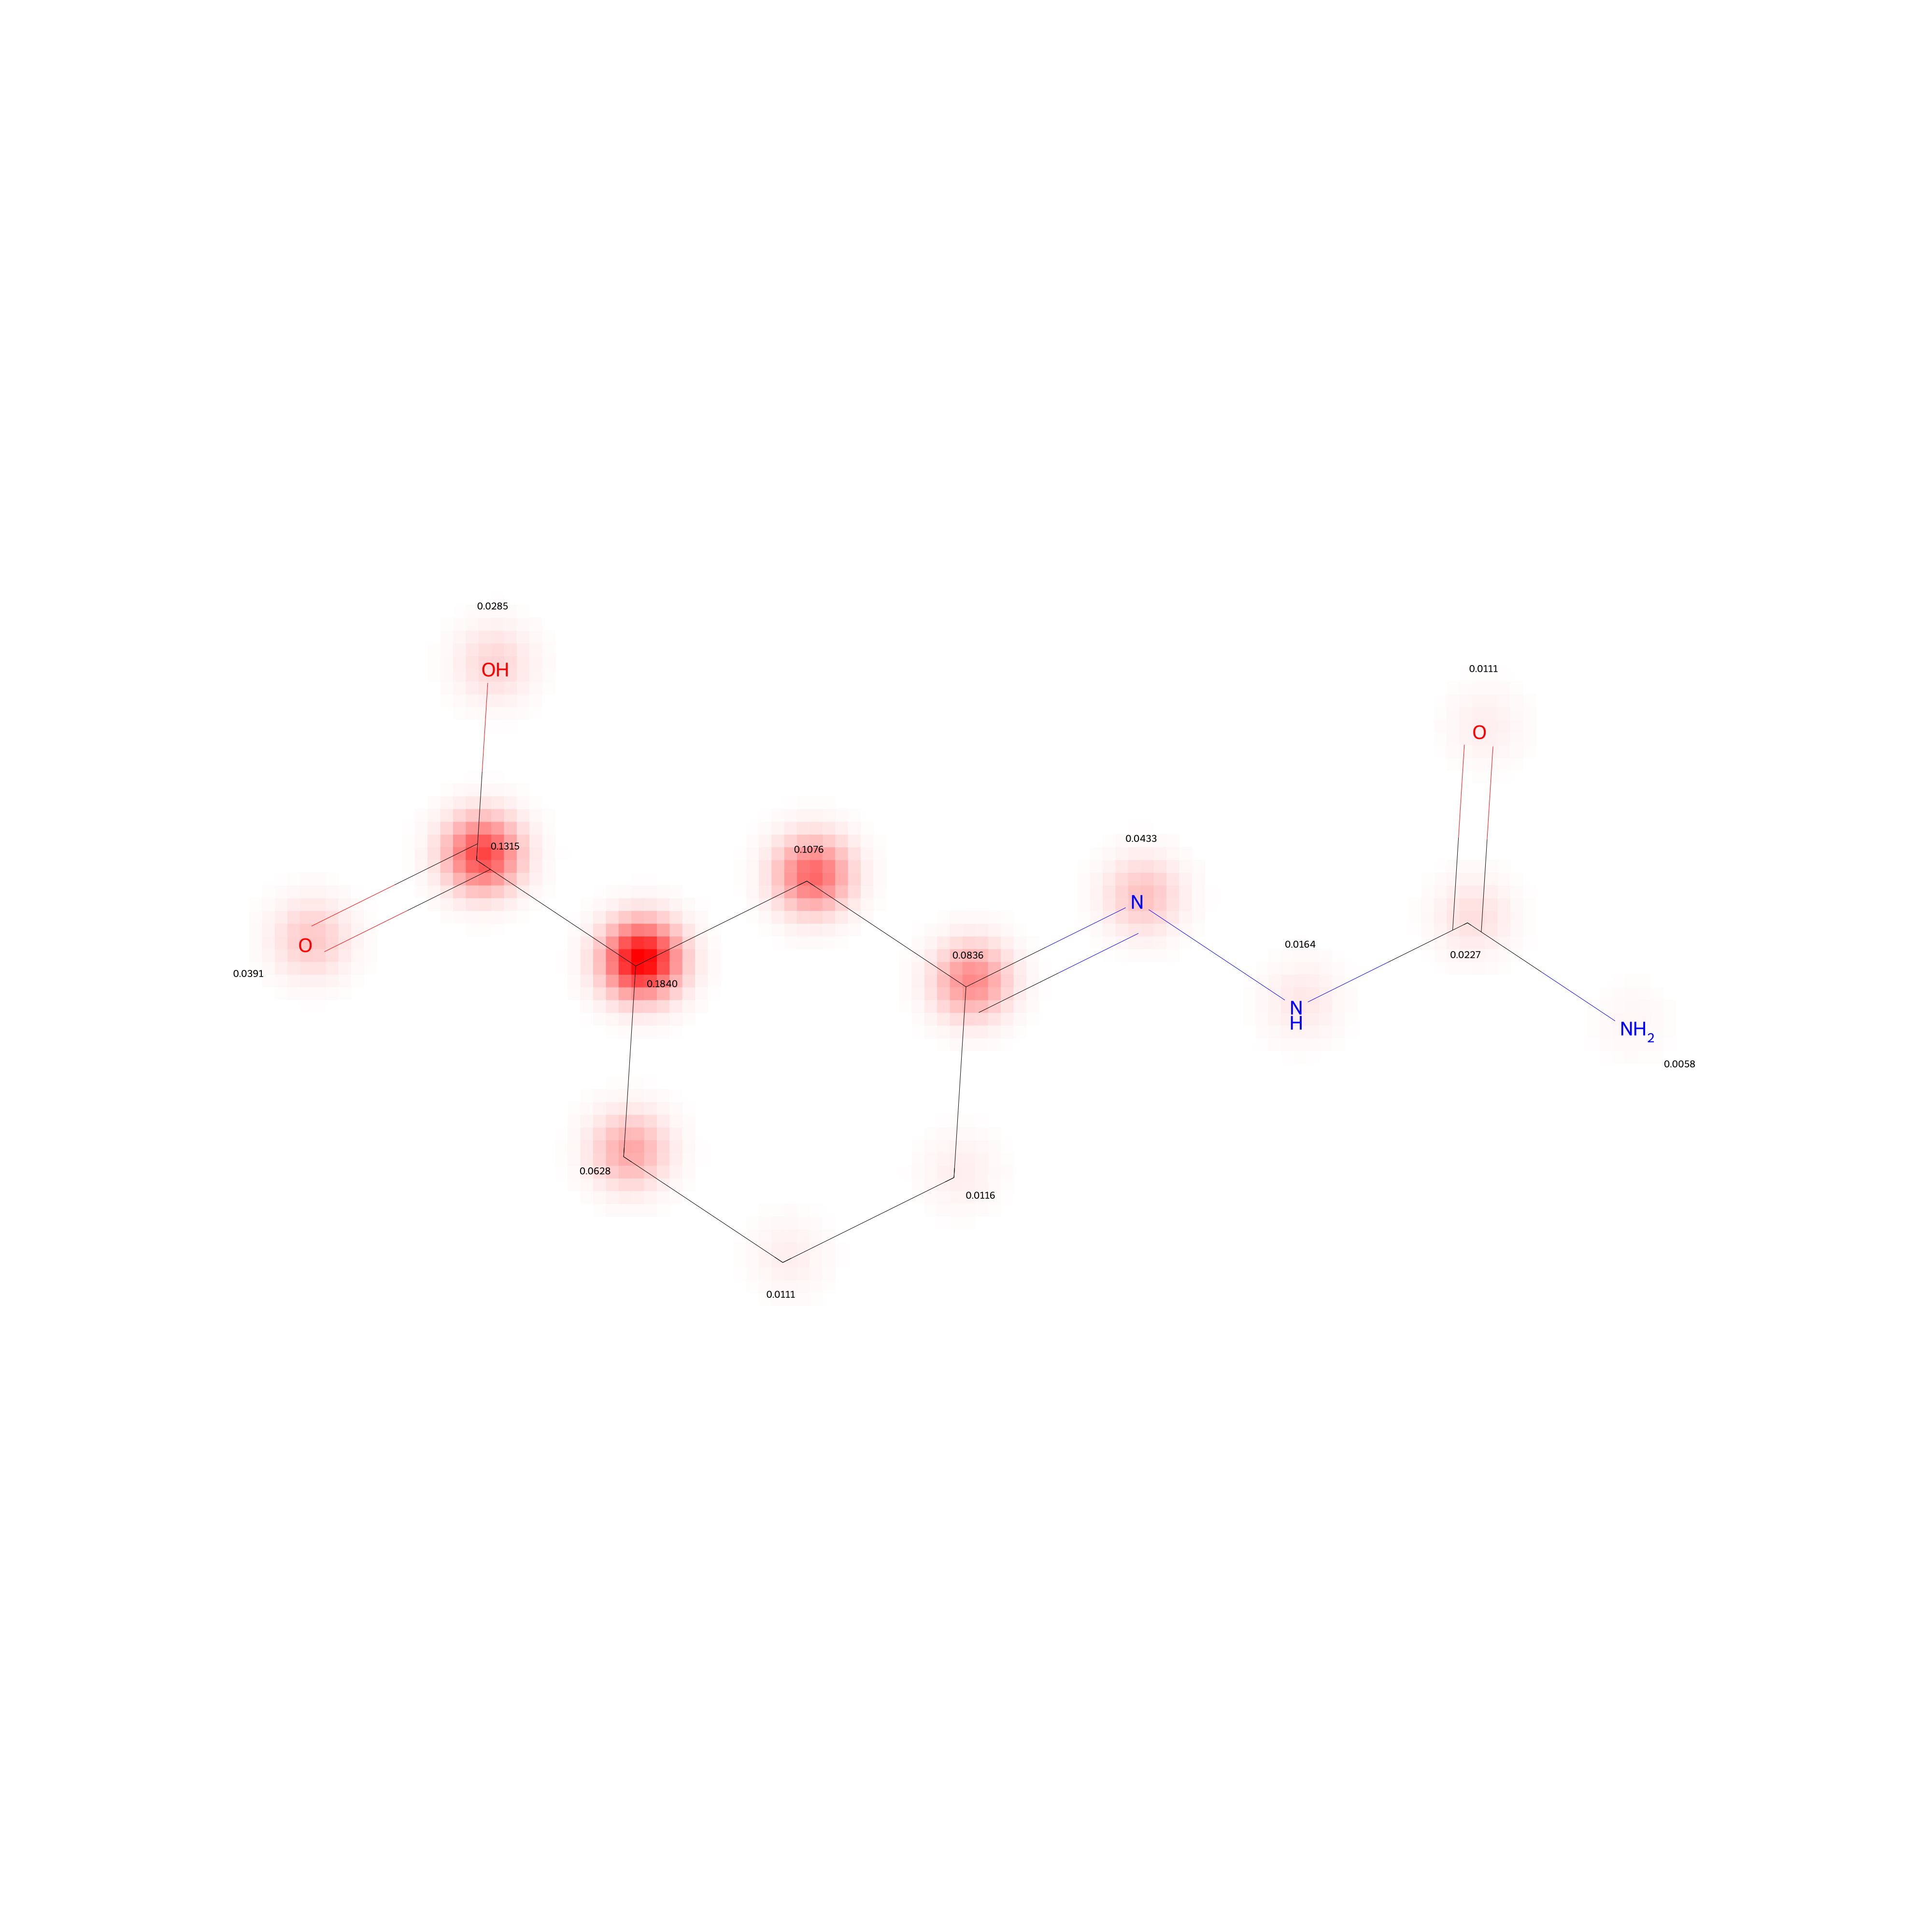

In [86]:
from datavis import visualize_atom_importance_from_mol

visualize_atom_importance_from_mol(mol, attributions)

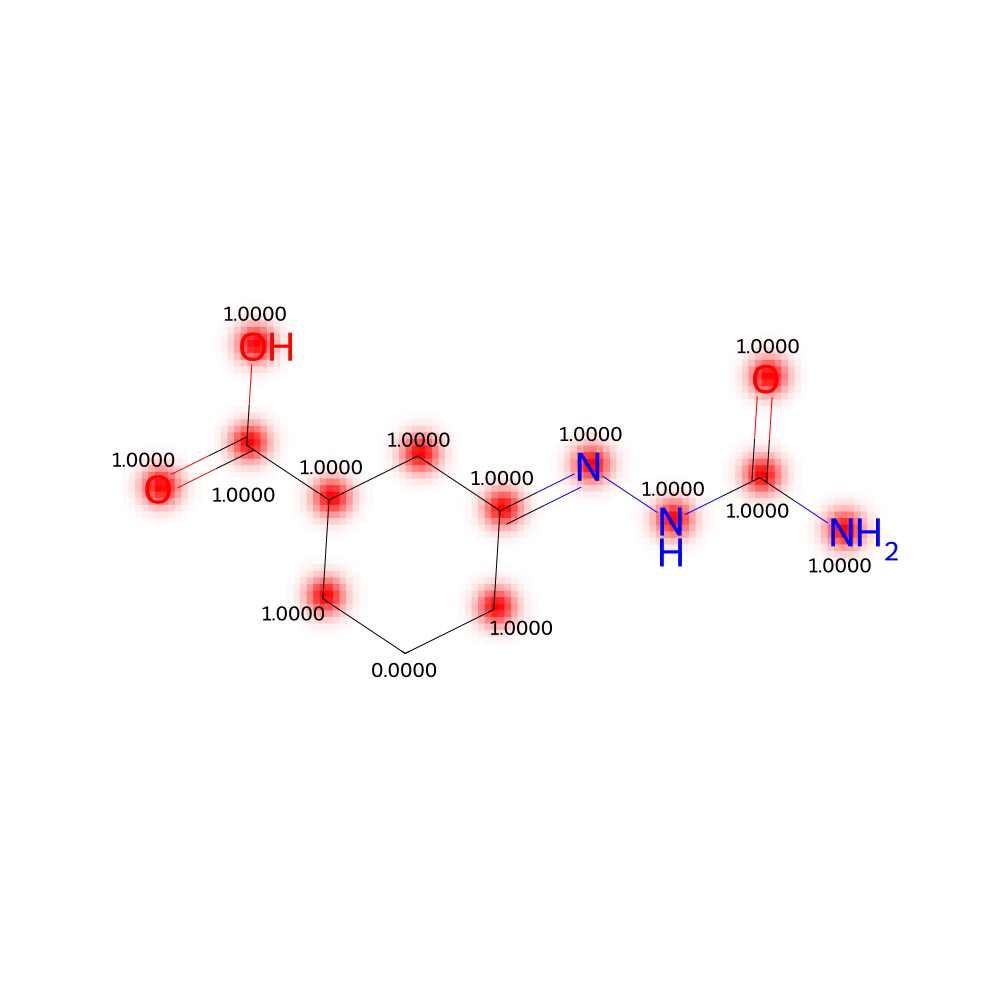

In [87]:
from highlight_smarts import visualize_smarts_match

visualize_smarts_match(mol, smarts)